In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import pandas as pd
import ctypes, assimulo, numpy as np
from assimulo.problem import Explicit_Problem
from assimulo.solvers import CVode 
import time
import sys
import io
import cma
import os
import glob
import re
import itertools
from scipy.interpolate import interp1d, LinearNDInterpolator
from scipy.ndimage import uniform_filter1d
from scipy.signal import argrelextrema, find_peaks
import functions_to_import as f_CoA
from setuptools import Extension, setup
from Cython.Build import cythonize
import importlib
import solver.model
importlib.reload(solver.model)
importlib.reload(solver.model.cwrapping)
from scipy.fft import fft, fftfreq
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [2]:
def interpolation2D(label,variables,matrix,list_name,v_fo,v_br):
    for i, (label_t, variable) in enumerate(zip(label, variables)):
        values = matrix[i]
        v_fo_interpolate = np.linspace(1, 0.2, 251)
        v_br_interpolate = np.linspace(1, 1.15, 251)
        X, Y = np.meshgrid(v_br_interpolate,v_fo_interpolate)
        interp = LinearNDInterpolator(list(zip(v_br,v_fo)), values)
        interp_values_2d = interp(X, Y)
        list_name.append(interp_values_2d)
    return list_name, v_fo_interpolate, v_br_interpolate

In [3]:
## nombre O2 ha cambiado

v_fo = [1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2]
v_da = np.linspace(1,0.6,9) 
v_lu = np.linspace(1,1.75,9) 
v_dv = [1,0.9,0.8,0.7,0.6,0.5] 
v_br = [1,1.05,1.1,1.15]

GA = 36
Tc = 0.43
density = 1.05
viscosity = (1.15+0.075*GA)/100

variables_S = [('RV', 'SO2'),('LV', 'SO2'),('Bif_AO1in_DA2in_dAOout', 'SO2'),('PLAC', 'SO2'),('Bif_BR1in_UB2in_SVCout', 'SO2')]
variables_pO = [('BR', 'pO2')]
label_s = ['SO2_AA','SO2_MPA','SO2_dAo','SO2_PLAC','SO2_SVC']
label_pO = ['pO2_BR']

data = np.load("default_constants.npz", allow_pickle=True)   
default_constants = {key: data[key] for key in data}

INTERPOLATION_S = []
INTERPOLATION_pO = []

regex = re.compile(r"O2_from_FO(\d+)_DA(\d+)_LUNG(\d+)_DV(\d+)_BRAIN(\d+).npz$", re.IGNORECASE)
mean_S = []

for i_dv, degree_dv in enumerate(v_dv): 
    v_fo_all = []
    v_br_all = []
    list_S = [[] for _ in range(len(label_s))]
    list_pO = [[] for _ in range(len(label_pO))]
    
    INTERPOLATION_S_dv = []
    INTERPOLATION_pO_dv = []
    
    # Use glob to get the list of files matching the pattern
    file_pattern = f"/Users/inmav/Downloads/O2_TGA_100/O2_from_FO*_DA*_LUNG*_DV{int(degree_dv*100)}_BRAIN*.npz"
    file_list = glob.glob(file_pattern) 
    print(len(file_list))

    for file_path in file_list:
        data_O2 = np.load(file_path)
        t_O2 = data_O2['voi']  
        results_O2 = data_O2['data']  
        names_O2 = data_O2['names'] 
        constants_O2 = data_O2['constants']
        names_constants_O2 = data_O2['names_constants']
        
        match = regex.search(os.path.basename(file_path))
        v_fo_all.append(round(int(match.group(1))/100,2)) 
        v_br_all.append(round((int(match.group(5))/100),2))

        for i in range(len(variables_S)):
            list_S[i].append(results_O2[np.where(np.all(names_O2 == variables_S[i], axis=1))[0][0]])
        for i in range(len(variables_pO)):
            list_pO[i].append(results_O2[np.where(np.all(names_O2 == variables_pO[i], axis=1))[0][0]])
                             
    # Interpolation
    INTERPOLATION_S_dv, v_fo_interpolate, v_br_interpolate = interpolation2D(label_s,variables_S,list_S,INTERPOLATION_S_dv,v_fo_all,v_br_all)
    INTERPOLATION_pO_dv, v_fo_interpolate, v_br_interpolate = interpolation2D(label_pO,variables_pO,list_pO,INTERPOLATION_pO_dv,v_fo_all,v_br_all)
    INTERPOLATION_S.append(INTERPOLATION_S_dv)
    INTERPOLATION_pO.append(INTERPOLATION_pO_dv)
    mean_S.append(np.mean(list_S[4]))
    
    print(np.shape(INTERPOLATION_S_dv))

np.savez('Results_matrix2D_100.npz', mean_S = mean_S, v_fo_interpolate = v_fo_interpolate, v_br_interpolate = v_br_interpolate, INTERPOLATION_S = np.transpose(INTERPOLATION_S, (1, 0, 2, 3)), INTERPOLATION_pO = np.transpose(INTERPOLATION_pO, (1, 0, 2, 3)), label_s = label_s, label_pO = label_pO, v_fo = v_fo, v_dv = v_dv, v_br = v_br)


36
(5, 251, 251)
36
(5, 251, 251)
36
(5, 251, 251)
36
(5, 251, 251)
36
(5, 251, 251)
36
(5, 251, 251)


In [4]:
GA = 36
Tc = 0.43
density = 1.05
viscosity = (1.15+0.075*GA)/100

v_fo = [1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2] 
v_da = np.linspace(1,0.6,9) 
v_lu = np.linspace(1,1.75,9)
v_dv = [1,0.9,0.8,0.7,0.6,0.5] 
v_br = [1,1.05,1.1,1.15]

variables_V = [('PA_RCL', 'Qo'), ('AA_RCL', 'Qo'), ('SVC_RCL', 'Qo'), ('Bif_PAin_LUNG1out_DA2out', 'Qo2'), ('Bif_DA1in_AI2in_AOout', 'Qo'), ('Bif_PAin_LUNG1out_DA2out', 'Qo1'), ('UV_RCL', 'Qo'), ('UV_RCL', 'Qo')]
variables_P = [('LUNG_RCL', 'Pi'), ('LA', 'Pi'), ('RA', 'Pi'), ('LV', 'Pi'), ('RV', 'Pi'), ('Bif_PAin_LUNG1out_DA2out', 'Pi'), ('Bif_AAin_AAA1out_BrachT2out', 'Pi'), 
               ('Bif_DA1in_AI2in_AOout', 'Pi2'), ('Bif_DA1in_AI2in_AOout', 'Pi1'), ('Bif_AOin_AO1out_INTE2out_HE3out_KID4out', 'Pi'), ('Bif_AOin_LEG1out_UA2out', 'Pi'), 
               ('Bif_BR1in_UB2in_SVCout', 'Pi1'), ('Bif_BR1in_UB2in_SVCout', 'Pi2'), ('Bif_SVC1in_IVC2in_DV3in_Coronary4in_RAout', 'Pi1'), ('HE_RC', 'Pi'), 
               ('Bif_KID1in_HE2in_LEG3in_IVCout', 'Pi2'), ('Bif_AOin_AO1out_INTE2out_HE3out_KID4out', 'Pi'), ('Bif_KID1in_HE2in_LEG3in_IVCout', 'Pi1'), 
               ('PLAC_RC', 'Pi'), ('Bif_UVin_DV1out_HE2out', 'Pi'), ('Bif_IVCin_FO1out_RA2out', 'Pi'), ('Bif_BRR1in_BRL2in_BRout', 'Pi')]
variables_W = [('PA_RCL', 'Qo'), ('AA_RCL', 'Qo'), ('AO2_RCL', 'Qo'), ('Bif_BRR1in_BRL2in_BRout', 'Qo'), 
               ('Bif_UBR1in_UBL2in_UBout', 'Qo'), ('SVC_RCL', 'Qo'), ('Bif_AOin_LEG1out_UA2out', 'Qo2'), ('PLAC_RC', 'Qo')]

label_v = ['Q_PA','Q_AA','Q_SVC','Q_DA','Q_dAO','Q_LUNG','Q_UV','Q_total']
label = ['lungs', 'left atrium', 'right atrium', 'left ventricle', 'right ventricle', 'main pulmonary artery', 'ascending aorta', 'aortic isthmus', 'ductus arteriosus', 
         'thoracic aorta', 'abdominal aorta', 'jugular vein', 'subclavian vein', 'superior vena cava', 'hepatic artery', 'hepatic vein', 'renal artery', 'renal vein', 
         'umbilical artery', 'umbilical vein', 'inferior vena cava', 'middle cerebral artery']
label_2 = ['Main pulmonary artery', 'Ascending aorta', 'Desdending aorta', 'Jugular vein', 'Subclavian vein', 'Superior vena cava', 
           'Umbilical artery', 'Umbilical vein']
radius = [0.3415,0.2984690662736599,0.25955,0.22,0.18755,0.17366,0.2,0.165915,0.345,0.227]

data = np.load("default_constants.npz", allow_pickle=True)   
default_constants = {key: data[key] for key in data}

healthy_values_P = np.zeros(len(label))
healthy_values_W = np.zeros(len(label_2))

data = np.load(f"/Users/inmav/Downloads/Results_TGA_Bart_brain2/Healthy_case.npz") #FO100_DA100_LUNG100_DV90_BRAIN100
t = data['voi']  
results = data['data']  
names = data['names']
constants = data['constants']
names_constants = data['names_constants']

for i in range(len(variables_P)):
    if label[i] == 'middle cerebral artery':
        P_LICA = results[:,np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi2'), axis=1))[0][0]]
        P_RICA = results[:,np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi1'), axis=1))[0][0]]
        healthy_values_P[i] = (np.max(P_LICA)+np.max(P_RICA))/2 
    else: 
        healthy_values_P[i] = np.max(results[:,np.where(np.all(names == variables_P[i], axis=1))[0][0]])

for i in range(len(variables_W)):
    healthy_values_W[i] = np.max(4*viscosity*results[:,np.where(np.all(names == variables_W[i], axis=1))[0][0]]/(np.pi*radius[i]**3))/1333  


INTERPOLATION_V = []
INTERPOLATION_P = []
INTERPOLATION_W = []

regex = re.compile(r"FO(\d+)_DA(\d+)_LUNG(\d+)_DV(\d+)_BRAIN(\d+).npz$", re.IGNORECASE)
file_pattern = f"/Users/inmav/Downloads/Results_TGA_100/FO*_DA*_LUNG*_DV*_BRAIN*.npz"
file_list = glob.glob(file_pattern) 
list_V = [[] for _ in range(len(label_v))]
list_P = [[] for _ in range(len(label))]
list_W = [[] for _ in range(len(label_2))]
v_fo_all = []
v_br_all = []
print(len(file_list))

for file_path in file_list:
    data = np.load(file_path)
    t = data['voi']  
    results = data['data']  
    names = data['names'] 
    constants = data['constants']
    names_constants = data['names_constants']
    
    match = regex.search(os.path.basename(file_path))
    v_fo_all.append(round(int(match.group(1))/100,2)) 
    v_br_all.append(round((int(match.group(5))/100),2))
    CCO = np.trapz(results[:,np.where(np.all(names == ('LV','Qo'), axis=1))[0][0]],t)/2 + np.trapz(results[:,np.where(np.all(names == ('RV','Qo'), axis=1))[0][0]],t)/2
    
    for i in range(len(label_v)):
        if i == 7:
            list_V[i].append(CCO)
        else:
            list_V[i].append((np.trapz(results[:,np.where(np.all(names == variables_V[i], axis=1))[0][0]],t)/2)/CCO*100)
            
    for i in range(len(variables_P)):
        if label[i] == 'middle cerebral artery':
            P_LICA = results[:,np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi2'), axis=1))[0][0]]
            P_RICA = results[:,np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi1'), axis=1))[0][0]]
            list_P[i].append((np.max(P_LICA)+np.max(P_RICA))/2)   
        else: 
            list_P[i].append(np.max(results[:,np.where(np.all(names == variables_P[i], axis=1))[0][0]]))

    for i in range(len(variables_W)):
        degree = 1
        if i == 0:
            degree = (default_constants['Rpa']/constants[np.where(np.all(names_constants == ['Parameters', 'Rpa'], axis=1))][0])**(1/4)
        if i == 1:
            degree = (default_constants['Raa']/constants[np.where(np.all(names_constants == ['Parameters', 'Raa'], axis=1))][0])**(1/4)
        if i == 3:
            degree = (default_constants['R_L_ICA']/constants[np.where(np.all(names_constants == ['Parameters', 'R_L_ICA'], axis=1))][0])**(1/4)
        if i == 5:
            degree = (default_constants['Rsvc']/constants[np.where(np.all(names_constants == ['Parameters', 'Rsvc'], axis=1))][0])**(1/4)

        rad = radius[i]*degree
        list_W[i].append(np.max(4*viscosity*results[:,np.where(np.all(names == variables_W[i], axis=1))[0][0]]/(np.pi*rad**3))/1333)
            
    
INTERPOLATION_V, v_fo_interpolate, v_br_interpolate = interpolation2D(label_v,variables_V,list_V,INTERPOLATION_V,v_fo_all,v_br_all)
INTERPOLATION_P, v_fo_interpolate, v_br_interpolate = interpolation2D(label,variables_P,list_P,INTERPOLATION_P,v_fo_all,v_br_all)
INTERPOLATION_W, v_fo_interpolate, v_br_interpolate = interpolation2D(label_2,variables_W,list_W,INTERPOLATION_W,v_fo_all,v_br_all)
    
np.savez('Results_matrix2D_QPW_100.npz', INTERPOLATION_V = INTERPOLATION_V, INTERPOLATION_P = INTERPOLATION_P, INTERPOLATION_W = INTERPOLATION_W, label_v = label_v, label = label, label_2 = label_2, v_fo = v_fo, v_dv = v_dv, v_br = v_br, healthy_values_P = healthy_values_P, healthy_values_W = healthy_values_W)


36


In [3]:
# Import interpolated data from Results_matrix.npz
data = np.load(f"Results_matrix2D_100.npz") 
v_fo_interpolate = data['v_fo_interpolate']
v_br_interpolate = data['v_br_interpolate']
INTERPOLATION_S = data['INTERPOLATION_S']
INTERPOLATION_pO = data['INTERPOLATION_pO']
v_fo = data['v_fo'] 
v_dv = data['v_dv']
v_br = data['v_br'] 
label_s = data['label_s']
label_pO = data['label_pO']
mean_S = data['mean_S']

data = np.load(f"Results_matrix2D_QPW_100.npz")
INTERPOLATION_V = data['INTERPOLATION_V'] 
INTERPOLATION_P = data['INTERPOLATION_P'] 
INTERPOLATION_W = data['INTERPOLATION_W']
healthy_values_P = data['healthy_values_P']
healthy_values_W = data['healthy_values_W']
label = data['label']
label_v = data['label_v']
label_2 = data['label_2']


In [30]:
c_s = [3,4,6,6,5] 

reference_label = []
reference_value = []
reference_fo = []
list_matrix = []
list_variation = []


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def create_2Dplot_contour_O2_5(label,interpolation,title,v_dv,v_fo,v_br,v_fo_interpolate,v_br_interpolate,c_pos,c_neg,list_variation,list_matrix,reference_label,reference_value,reference_dv,vmax,vmin,levels):
    save_images = True
    v_dv_plot = v_dv

    # Ticks positions
    v_fo_positions = [np.argmin(np.abs(v_fo_interpolate - value)) for value in v_fo]
    v_br_positions = [np.argmin(np.abs(v_br_interpolate - value)) for value in v_br]

    fig, axes = plt.subplots(1, len(v_dv_plot), figsize=(14, 3.5), sharey=True)

    list_matrix2 = []
    list_variation2 = []

    # Global range
    vmin = np.min(levels)
    vmax = np.max(levels)
    print(vmin)
    print(vmax)


    mid = (vmin + vmax) / 2.0
    span = (vmax - vmin)

    thr_outer = mid + 0.5 * span
    thr_inner = mid - 0.5 * span

    thr_mid_1 = mid + (5 / 15) * (span / 2)
    thr_mid_2 = mid - (5 / 15) * (span / 2)
    thr_mid_w1 = mid + (10 / 15) * (span / 2)
    thr_mid_w2 = mid - (10 / 15) * (span / 2)
    
    

    for i in range(len(v_dv_plot)):
        ax = axes[i]

        # closest v_fo
        v_dv_value = v_dv[(np.abs(v_dv - v_dv_plot[i])).argmin()]
        index = np.where(v_dv == v_dv_value)[0][0]

        matrix = interpolation[index]
        list_variation2.append(matrix)

        ax.imshow(matrix,cmap='turbo',origin='lower',aspect='auto',vmin=vmin,vmax=vmax,alpha=1)
        v_color =['k'] * len(levels)
        v_color[0] = 'w'
        v_color[-1] = 'w'

        CS = ax.contour(
            np.linspace(0, len(v_br_interpolate), len(v_br_interpolate)),
            np.linspace(0, len(v_fo_interpolate), len(v_fo_interpolate)),
            matrix,
            levels=levels,
            colors=v_color)

        # Automatic positions for contour labels
        closest_coordinates = []
        for line in CS.collections:
            if line.get_paths():
                x_value = line.get_paths()[0].get_extents().get_points().mean(axis=0)[0]
                coordinates_list = line.get_paths()[0].vertices
                index_closest_x = np.argmin(np.abs(coordinates_list[:, 0] - x_value))
                closest_coordinates.append(tuple(coordinates_list[index_closest_x]))

        if not (title == 'Wall shear stress' and label == 'Ascending aorta' and i == 4):
            ax.clabel(CS, inline=True, fontsize=10, manual=closest_coordinates)

        # Axis
        ax.set_yticks(v_fo_positions, np.round(np.asarray(v_fo) * 100).astype(int), fontsize=12)
        ax.set_xticks(v_br_positions, np.round(np.asarray(v_br) * 100).astype(int), fontsize=12)

        ax.set_ylim([min(v_fo_positions), max(v_fo_positions)])
        ax.set_xlim([min(v_br_positions), max(v_br_positions)])

        ax.set_xlabel('Brain vessels radii (%)', fontsize=13)
        ax.set_ylabel('FO area (%)', fontsize=13)
        ax.set_title(f'{int(v_dv_plot[i] * 100)}% shunting DV-FO', fontsize=14)
        

        matrix_2 = np.ones(np.shape(matrix)) * 100
        matrix_2[matrix >= vmax] = c_pos
        matrix_2[matrix <= vmin] = c_neg
        matrix_2[(matrix > vmin) & (matrix < vmax)] = 2
        matrix_2[(matrix >= thr_mid_w2) & (matrix <= thr_mid_w1)] = 1
        matrix_2[(matrix >= thr_mid_2) & (matrix <= thr_mid_1)] = 0

        list_matrix2.append(matrix_2)

        # References
        if np.any(matrix >= vmax):
            reference_label.append(f'{title} at {label} >= {vmax}')
            reference_value.append(c_pos)
            reference_dv.append(v_dv_value)

        if np.any(matrix <= vmin):
            reference_label.append(f'{title} at {label} <= {vmin}')
            reference_value.append(c_neg)
            reference_dv.append(v_dv_value)

    fig.suptitle(f'{title} at {label}', fontsize=16, y=0.96)
    plt.tight_layout()

    list_matrix.append(list_matrix2)
    list_variation.append(list_variation2)
    
    if save_images:
        plt.savefig(f"./Plots/100_SO2_{label}.pdf", format='pdf')
    plt.show()
    
    # Colorbar
    fig_cbar, ax_cbar = plt.subplots(figsize=(0.9, 2.5))

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='turbo', norm=norm)
    sm.set_array([])

    cbar = fig_cbar.colorbar(sm, cax=ax_cbar)
    cbar.set_label('Percentage of change', fontsize=14)

    nticks = 5
    ticks = np.linspace(vmin, vmax, nticks)

    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])

    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    # Save images
    plt.savefig(f"./Plots/100_SO2_colorbar_{label}.pdf", format='pdf', bbox_inches='tight') 

    plt.show()

    return list_variation, list_matrix, reference_label, reference_value, reference_dv, c_pos, c_neg
  

48
60


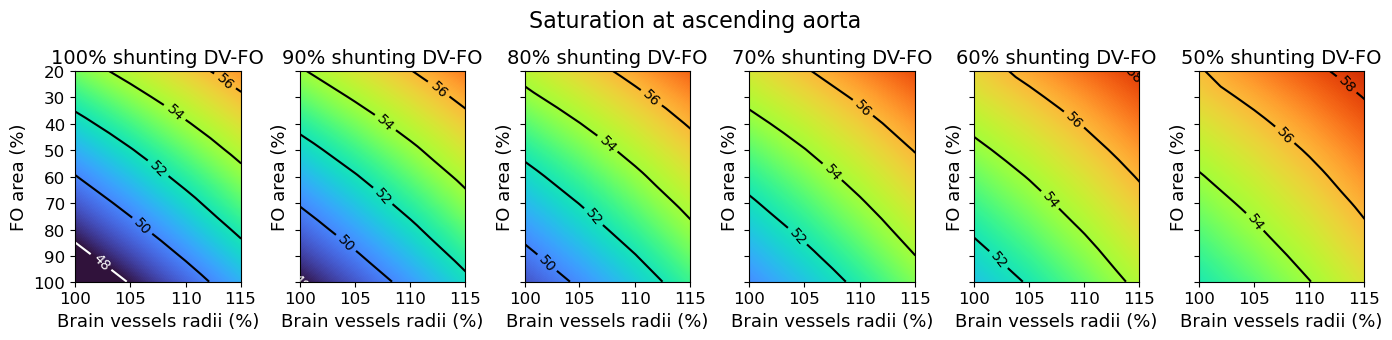

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


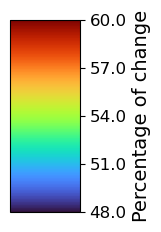

42
64


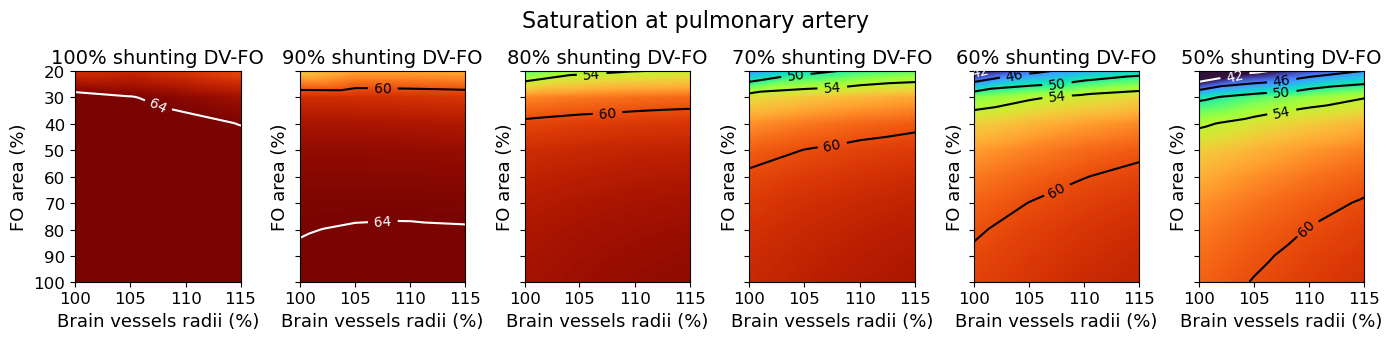

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


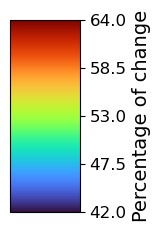

54
60


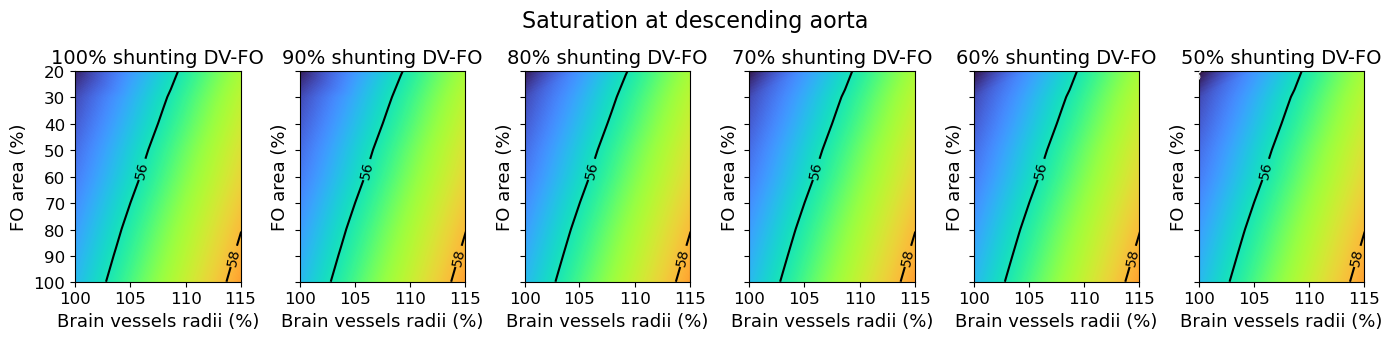

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


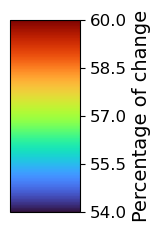

78
86


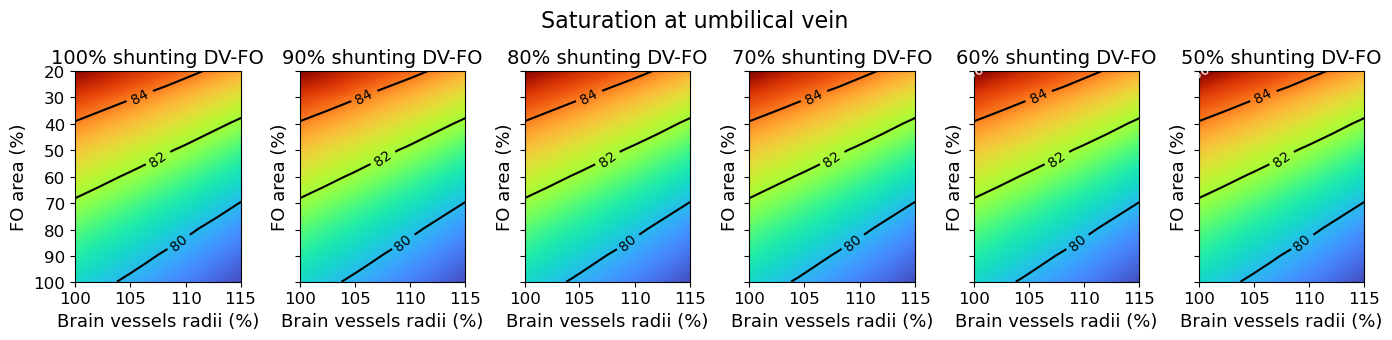

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


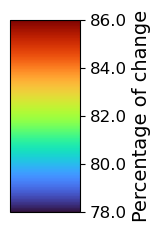

28
52


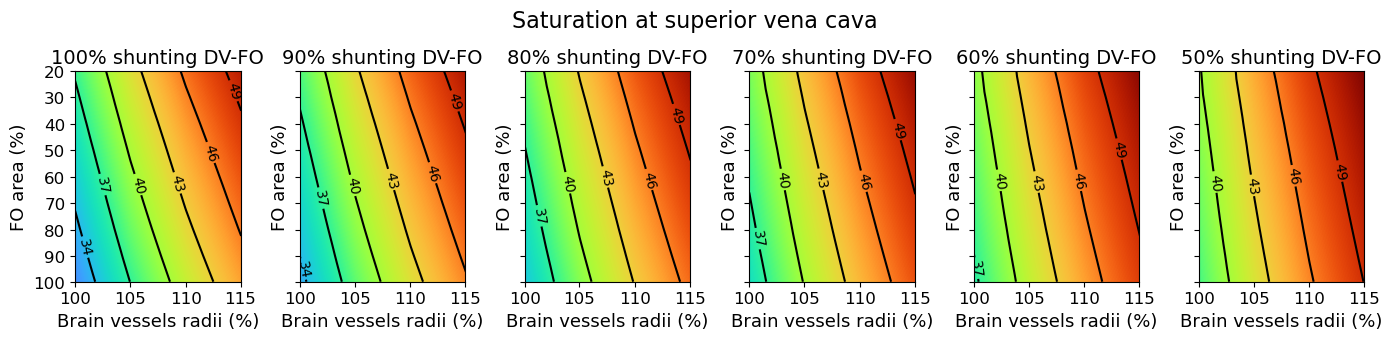

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


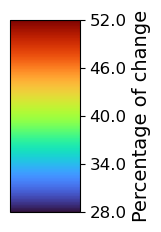

In [32]:
label_s = ['ascending aorta','pulmonary artery','descending aorta','umbilical vein','superior vena cava']
smax_v = [64,58,58,84,51]
smin_v = [52,44,46,74,37]
levels_s = [[48,50,52,54,56,58,60],[42,46,50,54,60,64],[54,56,58,60],[78,80,82,84,86],[28,31,34,37,40,43,46,49,52]]

for i in range(len(INTERPOLATION_S)):
    c_pos = c_s[i]
    c_neg = c_s[i]
    smax = smax_v[i]
    smin = smin_v[i]
    list_variation, list_matrix, reference_label, reference_value, reference_dv, c_pos, c_neg = create_2Dplot_contour_O2_5(label_s[i], INTERPOLATION_S[i], 'Saturation', v_dv, v_fo, v_br, v_fo_interpolate, v_br_interpolate, c_pos, c_neg, list_variation, list_matrix, reference_label, reference_value, reference_fo, smax, smin, levels_s[i])


13
20


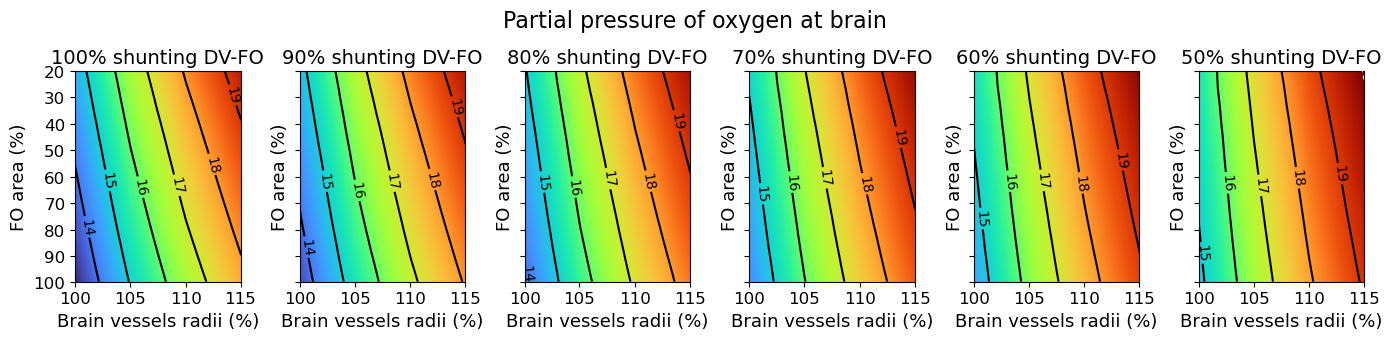

/var/folders/3q/prr4_tks7093c_x_3w4m6s4m0000gn/T/ipykernel_5913/1998728628.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


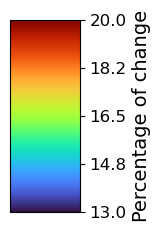

In [33]:
label_pO = ['brain']
smax_v = [64]
smin_v = [52]
levels_pO = [[13,14,15,16,17,18,19,20]]

for i in range(len(INTERPOLATION_pO)):
    c_pos = c_s[i]
    c_neg = c_s[i]
    smax = smax_v[i]
    smin = smin_v[i]
    list_variation, list_matrix, reference_label, reference_value, reference_dv, c_pos, c_neg = create_2Dplot_contour_O2_5(label_pO[i], INTERPOLATION_pO[i], 'Partial pressure of oxygen', v_dv, v_fo, v_br, v_fo_interpolate, v_br_interpolate, c_pos, c_neg, list_variation, list_matrix, reference_label, reference_value, reference_fo, smax, smin, levels_pO[i])


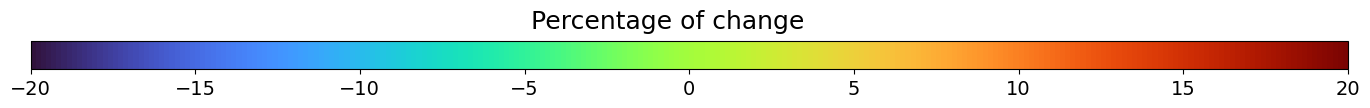

In [16]:
fig, ax = plt.subplots(figsize=(17, 0.75))
fig.subplots_adjust(bottom=0.5)

cmap = mpl.cm.turbo
norm = mpl.colors.Normalize(vmin=-20, vmax=+20)

cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
ax.xaxis.set_tick_params(labelsize=14)
fig.suptitle('Percentage of change', fontsize=18, position=(0.5, 1.3))
plt.savefig(f"./Plots/Legend_imshow.pdf", format='pdf')


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

def create_2Dplot_contour_all2(
    labels, interpolation_v, title,
    v_fo, v_br, v_fo_interpolate, v_br_interpolate,
    smax_v, smin_v, variable,
    c_pos=2, c_neg=3, global_range=False, healthy_values=None, save_images=True):

    if global_range:
        interpolation_v = np.asarray(interpolation_v)
        healthy_values = np.asarray(healthy_values)
        interpolation_v = interpolation_v / healthy_values[:, None, None] * 100 - 100
    else:
        interpolation_v = np.asarray(interpolation_v)
        
    nplots = len(labels)
    if global_range: 
        ncols = 4
    else:
        ncols = 4
    nrows = math.ceil(nplots / ncols)

    if interpolation_v.shape[0] != nplots:
        raise ValueError(f"El número de mapas ({interpolation_v.shape[0]}) no coincide con el número de labels ({nplots})")
    if len(smax_v) != nplots or len(smin_v) != nplots:
        raise ValueError("smax_v y smin_v deben tener la misma longitud que labels")

    # Real size of each matrix
    ny = interpolation_v.shape[1]
    nx = interpolation_v.shape[2]
    aspect_ratio = nx / ny 

    # Ticks positions
    v_fo_positions = [np.argmin(np.abs(v_fo_interpolate - value)) for value in v_fo]
    v_br_positions = [np.argmin(np.abs(v_br_interpolate - value)) for value in v_br]

    # Size of each subplot based on the real proportion of the map
    if global_range:
        base_height_per_row = 3.8
    else:
        base_height_per_row = 4.8
    base_width_per_col = base_height_per_row * aspect_ratio  

    fig_width = ncols * base_width_per_col
    fig_height = nrows * base_height_per_row

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), sharex=True, sharey=True, constrained_layout=True)

    axes = np.array(axes).reshape(-1)

    list_variation = []
    list_matrix = []

    for i in range(nplots):
        ax = axes[i]
        matrix = interpolation_v[i]
        label_i = labels[i]

        if global_range:
            vmin = -20
            vmax = 20
            levels = np.linspace(vmin, vmax, 9)

        else:
            vmin = np.min(interpolation_v[i])
            vmax = np.max(interpolation_v[i])
            levels = np.linspace(vmin, vmax, 7)
            levels = levels[1:6]
        

        mid = (vmin + vmax) / 2.0
        span = vmax - vmin

        thr_mid_1  = mid + (5 / 15) * (span / 2)
        thr_mid_2  = mid - (5 / 15) * (span / 2)
        thr_mid_w1 = mid + (10 / 15) * (span / 2)
        thr_mid_w2 = mid - (10 / 15) * (span / 2)

        list_variation.append(matrix)

        im = ax.imshow(matrix,cmap='turbo',origin='lower',aspect='equal',vmin=vmin,vmax=vmax,alpha=1)

        CS = ax.contour(np.arange(nx),np.arange(ny),matrix,levels=levels,colors=('k', 'k', 'k', 'k', 'k'),linewidths=1.2)

        # Automatic positions for contour labels 
        closest_coordinates = []
        for collection in CS.collections:
            if collection.get_paths():
                path = collection.get_paths()[0]
                x_value = path.get_extents().get_points().mean(axis=0)[0]
                coordinates_list = path.vertices
                index_closest_x = np.argmin(np.abs(coordinates_list[:, 0] - x_value))
                closest_coordinates.append(tuple(coordinates_list[index_closest_x]))

        if closest_coordinates:
            ax.clabel(CS, inline=True, fontsize=16, manual=closest_coordinates)

        # Ticks
        ax.set_xticks(v_br_positions)
        ax.set_xticklabels(np.round(np.asarray(v_br) * 100).astype(int), fontsize=16)

        ax.set_yticks(v_fo_positions)
        ax.set_yticklabels(np.round(np.asarray(v_fo) * 100).astype(int), fontsize=16)

        ax.set_xlim(min(v_br_positions), max(v_br_positions))
        ax.set_ylim(min(v_fo_positions), max(v_fo_positions))

        ax.set_title(label_i, fontsize=20, pad=10)

        # Only ylabel on first column
        if i % ncols == 0:
            ax.set_ylabel('FO area (%)', fontsize=20)
        else:
            ax.tick_params(labelleft=False)

        # Only xlabel on last row
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel('Brain vessels radii (%)', fontsize=20)

        matrix_2 = np.ones(np.shape(matrix)) * 100
        matrix_2[matrix >= vmax] = c_pos
        matrix_2[matrix <= vmin] = c_neg
        matrix_2[(matrix > vmin) & (matrix < vmax)] = 2
        matrix_2[(matrix >= thr_mid_w2) & (matrix <= thr_mid_w1)] = 1
        matrix_2[(matrix >= thr_mid_2) & (matrix <= thr_mid_1)] = 0

        list_matrix.append(matrix_2)

        # Colorbar for each subplot
        if not global_range: 
            cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
            ticks = np.linspace(vmax, vmin, 5)
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
            cbar.ax.tick_params(labelsize=16)

    for j in range(nplots, len(axes)):
        axes[j].axis('off')

    if save_images:
        fig.savefig(f"./Plots/100_{variable}_all.pdf", format='pdf', bbox_inches='tight')

    plt.show()

    return list_variation, list_matrix, c_pos, c_neg

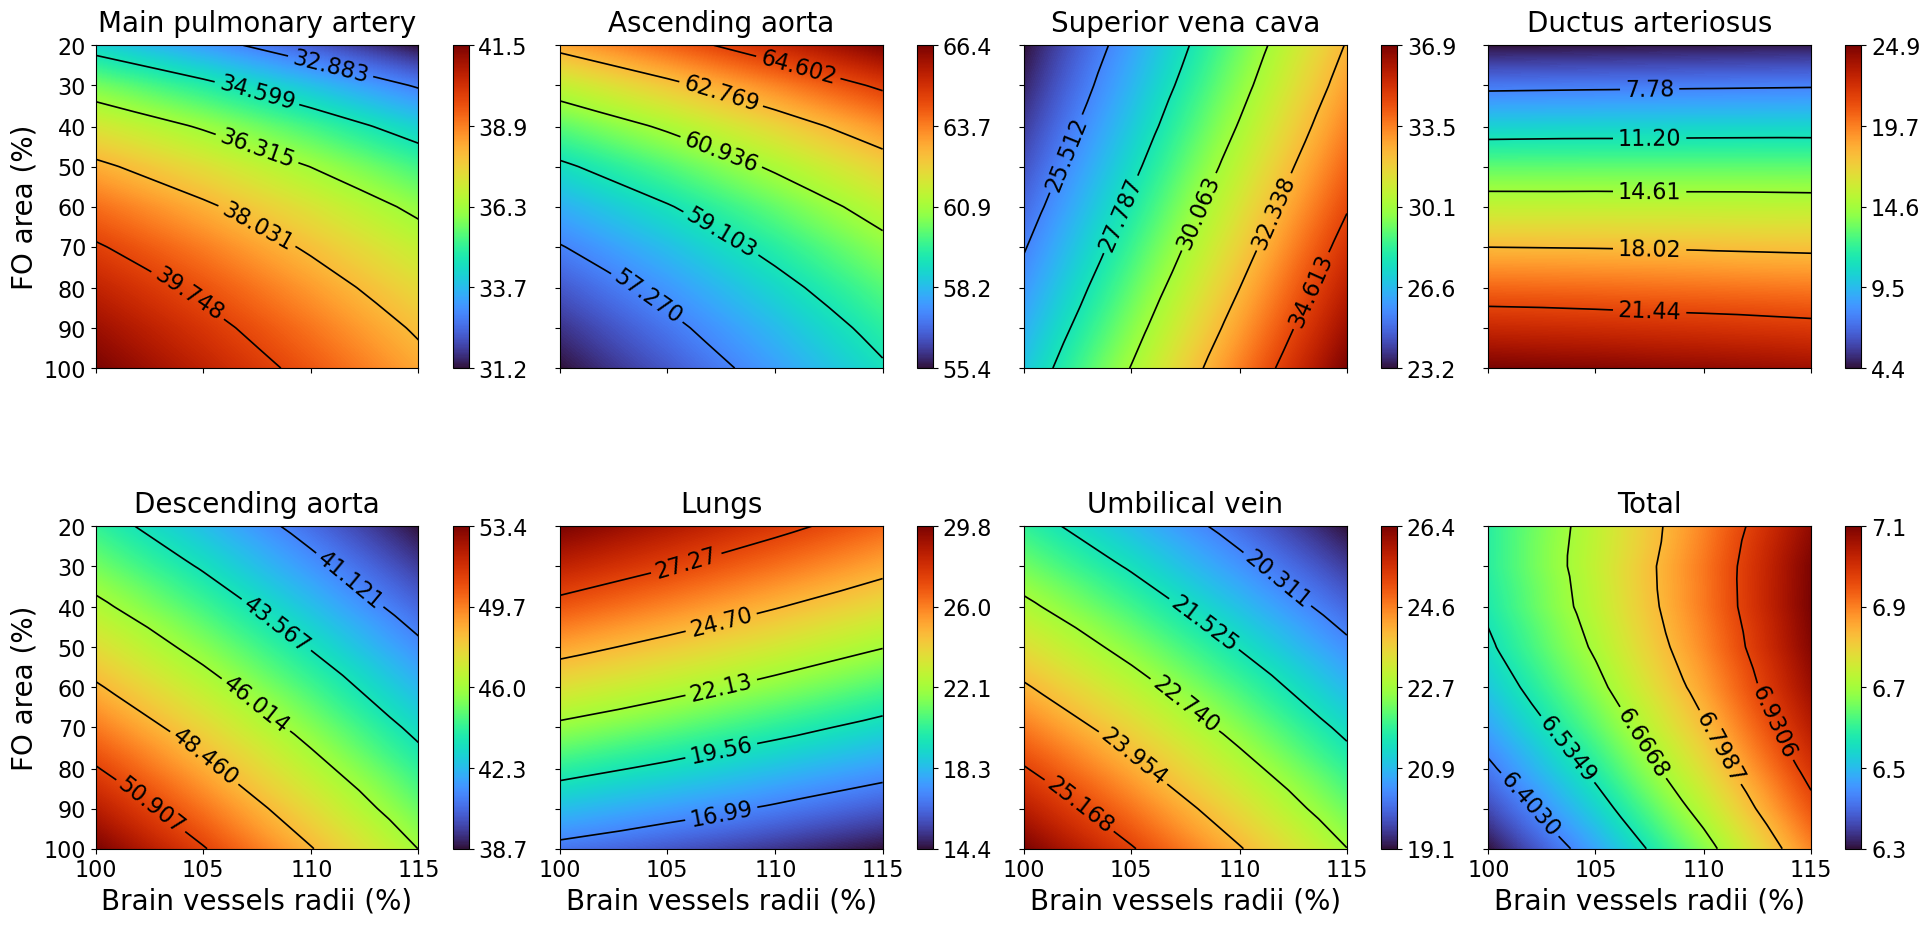

In [18]:
labels = ['Main pulmonary artery', 'Ascending aorta', 'Superior vena cava', 'Ductus arteriosus', 'Descending aorta', 'Lungs', 'Umbilical vein', 'Total']
smax_v = [61, 48, 38, 46, 59, 22, 35, 100]
smin_v = [48, 36, 23, 31, 43, 11, 22, 0]

c_pos = 2
c_neg = 3

list_variation = []
list_matrix = []

list_variation, list_matrix, c_pos, c_neg = create_2Dplot_contour_all2(
    labels=labels,
    interpolation_v=INTERPOLATION_V,
    title='Percentage of CCO',
    v_fo=v_fo,
    v_br=v_br,
    v_fo_interpolate=v_fo_interpolate,
    v_br_interpolate=v_br_interpolate,
    smax_v=smax_v,
    smin_v=smin_v,
    variable='Q',
    c_pos=c_pos,
    c_neg=c_neg,
    global_range=False,
    healthy_values=None,
    save_images=True)

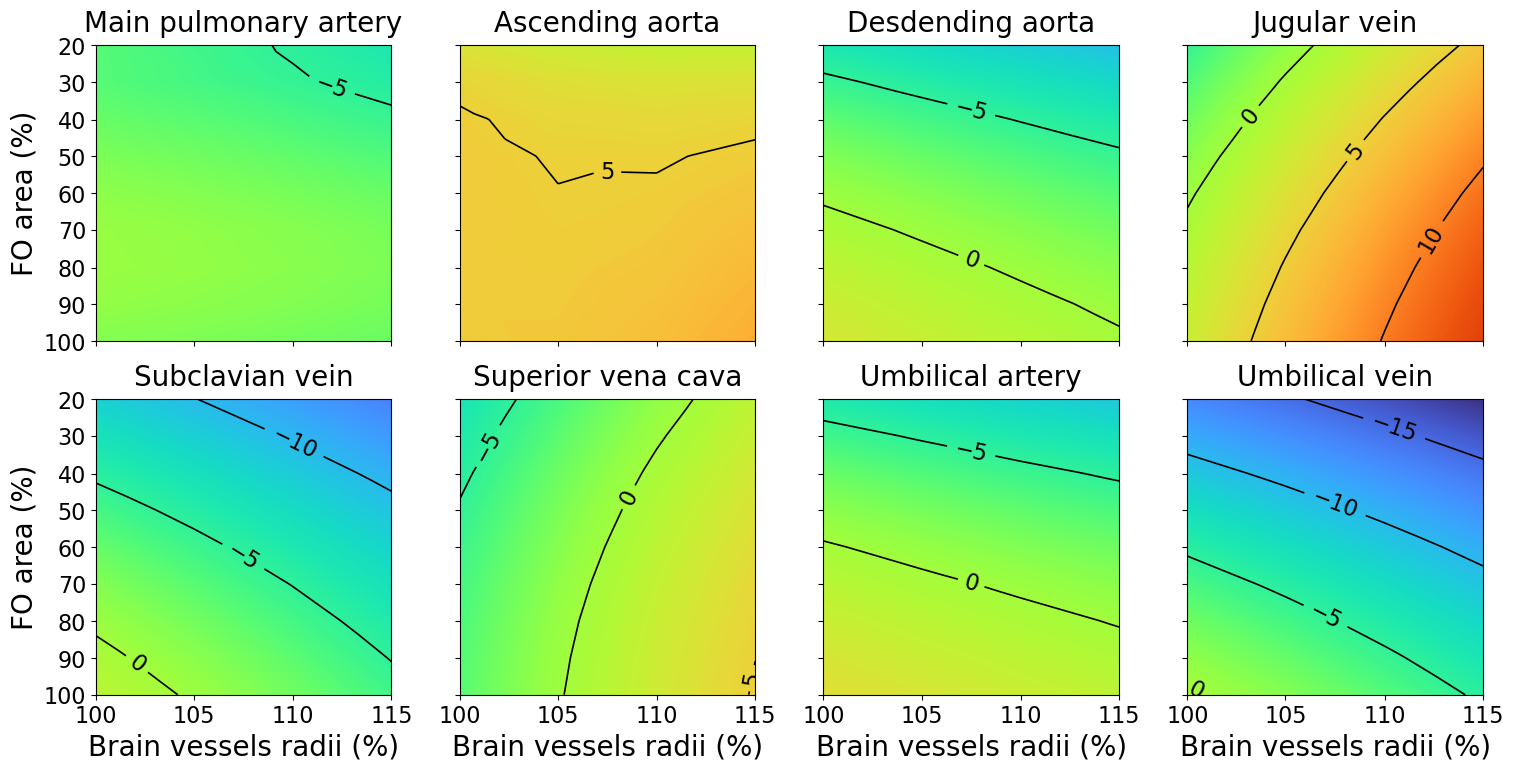

In [19]:
labels = label_2
smax_v = [61, 48, 38, 46, 59, 22, 35, 100]
smin_v = [48, 36, 23, 31, 43, 11, 22, 0]

c_pos = 2
c_neg = 3

list_variation = []
list_matrix = []

list_variation, list_matrix, c_pos, c_neg = create_2Dplot_contour_all2(
    labels=labels,
    interpolation_v=INTERPOLATION_W,
    title='Percentage of CCO',
    v_fo=v_fo,
    v_br=v_br,
    v_fo_interpolate=v_fo_interpolate,
    v_br_interpolate=v_br_interpolate,
    smax_v=smax_v,
    smin_v=smin_v,
    variable='W',
    c_pos=c_pos,
    c_neg=c_neg,
    global_range=True,
    healthy_values=healthy_values_W,
    save_images=True)

In [3]:
v_fo = [1,0.2,1,1,0.2,0.2,1,0.2] 
v_da = [1,0.6,1,1,0.6,0.6,1,0.6] 
v_lu = [1,0.47,1,1,0.47,0.47,1,0.47]
v_dv = [1,0.5,0.5,1,0.5,1,0.5,0.5] 
v_br = [1,1,1,1.15,1,1.15,1.15,1.15] 

print(v_fo[1])
print(v_dv[1])

0.2
0.5


In [4]:
print(v_fo[4])
print(v_dv[4])

0.2
0.5


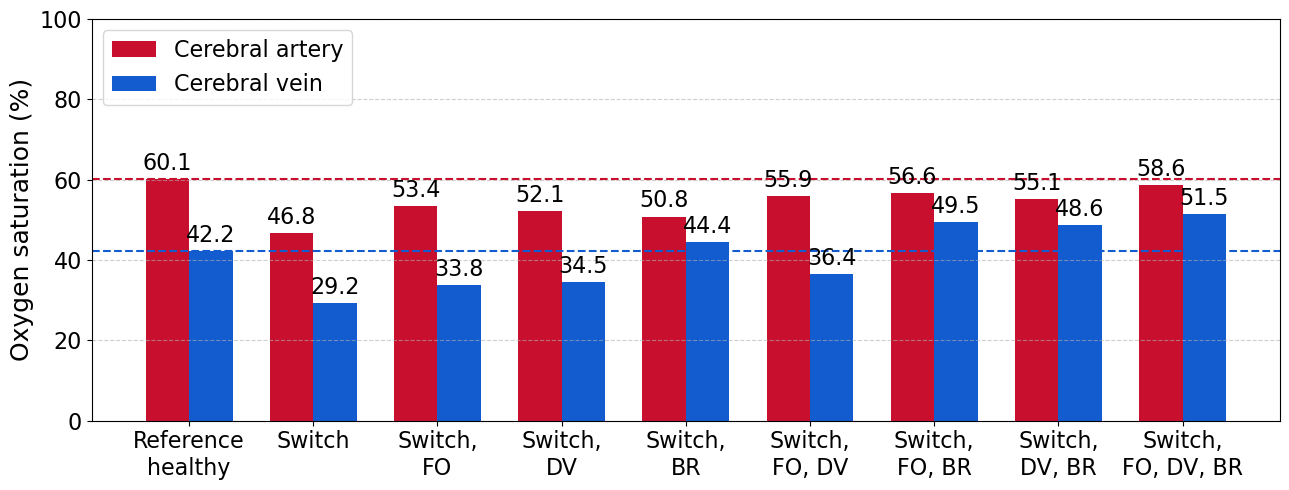

In [4]:
v_fo = [1,0.2,1,1,0.2,0.2,1,0.2] 
v_da = [1,0.6,1,1,0.6,0.6,1,0.6] 
v_lu = [1,0.47,1,1,0.47,0.47,1,0.47]
v_dv = [1,1,0.5,1,0.5,1,0.5,0.5] 
v_br = [1,1,1,1.15,1,1.15,1.15,1.15] 

GA = 36
Tc = 0.43
density = 1.05
viscosity = (1.15+0.075*GA)/100


S_before = [60.1]
S_after = [42.2]

for index in range(len(v_dv)): 

    data_O2 = np.load(f"/Users/inmav/Downloads/O2_TGA_100/O2_from_FO{int(round(v_fo[index]*100))}_DA{int(round(v_da[index]*100))}_LUNG{int(round(v_lu[index]*100))}_DV{int(round(v_dv[index]*100))}_BRAIN{int(round(v_br[index]*100))}.npz") 
    t_O2 = data_O2['voi']  
    results_O2 = data_O2['data']  
    names_O2 = data_O2['names'] 
    constants_O2 = data_O2['constants']
    names_constants_O2 = data_O2['names_constants']

    S_before.append(np.round(results_O2[np.where(np.all(names_O2 == ('Bif_UPin_BR1out_UB2out', 'SO2_1'), axis=1))[0][0]],1))
    S_after.append(np.round(results_O2[np.where(np.all(names_O2 == ('BR', 'SO2'), axis=1))[0][0]],1))
    

locations = ["Reference\nhealthy","Switch","Switch,\nFO","Switch,\nDV","Switch,\nBR","Switch,\nFO, DV","Switch,\nFO, BR","Switch,\nDV, BR","Switch,\nFO, DV, BR"]


# Positions
x = np.arange(len(locations))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x - width/2, S_before, width, label='Cerebral artery', color='#C8102E')
bars2 = ax.bar(x + width/2, S_after, width, label='Cerebral vein', color='#125CCF')

ax.bar_label(bars1, padding=3, fontsize=16, fmt='%.1f')
ax.bar_label(bars2, padding=3, fontsize=16, fmt='%.1f')

# Format
plt.axhline(60.1, color='#C8102E', linestyle = '--')
plt.axhline(42.2, color='#125CCF', linestyle = '--')
plt.xticks(x, locations, ha='center',fontsize=16)
ax.set_yticks(np.arange(0, 101, 20))
plt.yticks(fontsize=16)
plt.ylabel('Oxygen saturation (%)',fontsize=18)
plt.legend(fontsize=16, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim([0,100])

plt.tight_layout()
fig.savefig(f"./Plots/100_SO2_brain_scenarios.pdf", format='pdf', bbox_inches='tight')
plt.show()

/Users/inmav/Downloads/Results_TGA_100/FO100_DA100_LUNG100_DV100_BRAIN100.npz
MCA PI = 1.8390936851501465
/Users/inmav/Downloads/Results_TGA_100/FO80_DA90_LUNG80_DV100_BRAIN100.npz
MCA PI = 1.9269758462905884
/Users/inmav/Downloads/Results_TGA_100/FO60_DA80_LUNG65_DV100_BRAIN100.npz
MCA PI = 1.92941153049469
/Users/inmav/Downloads/Results_TGA_100/FO40_DA70_LUNG55_DV100_BRAIN100.npz
MCA PI = 1.9491833448410034
/Users/inmav/Downloads/Results_TGA_100/FO20_DA60_LUNG47_DV100_BRAIN100.npz
MCA PI = 1.9519026279449463
/Users/inmav/Downloads/Results_TGA_100/FO100_DA100_LUNG100_DV100_BRAIN105.npz
MCA PI = 1.776789665222168
/Users/inmav/Downloads/Results_TGA_100/FO80_DA90_LUNG80_DV100_BRAIN105.npz
MCA PI = 1.8085623979568481
/Users/inmav/Downloads/Results_TGA_100/FO60_DA80_LUNG65_DV100_BRAIN105.npz
MCA PI = 1.8348335027694702
/Users/inmav/Downloads/Results_TGA_100/FO40_DA70_LUNG55_DV100_BRAIN105.npz
MCA PI = 1.821894884109497
/Users/inmav/Downloads/Results_TGA_100/FO20_DA60_LUNG47_DV100_BRAIN105.

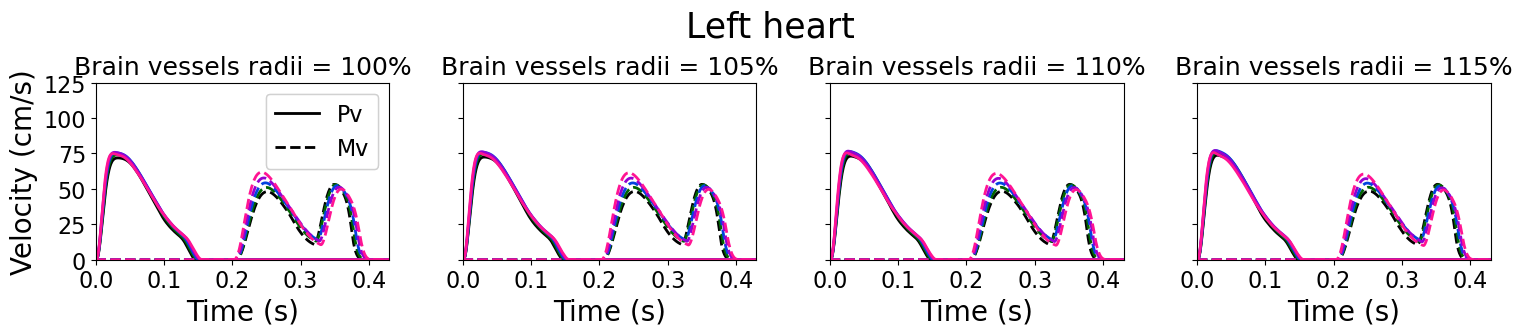

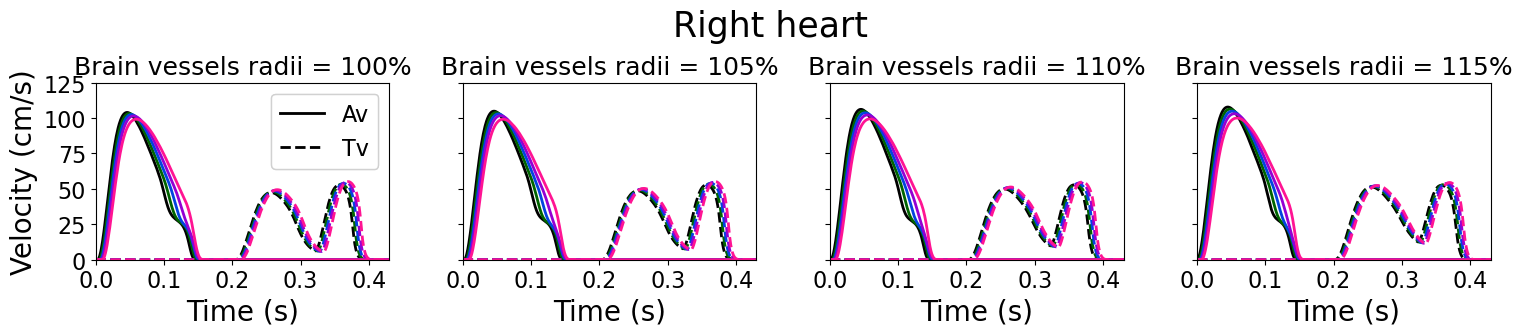

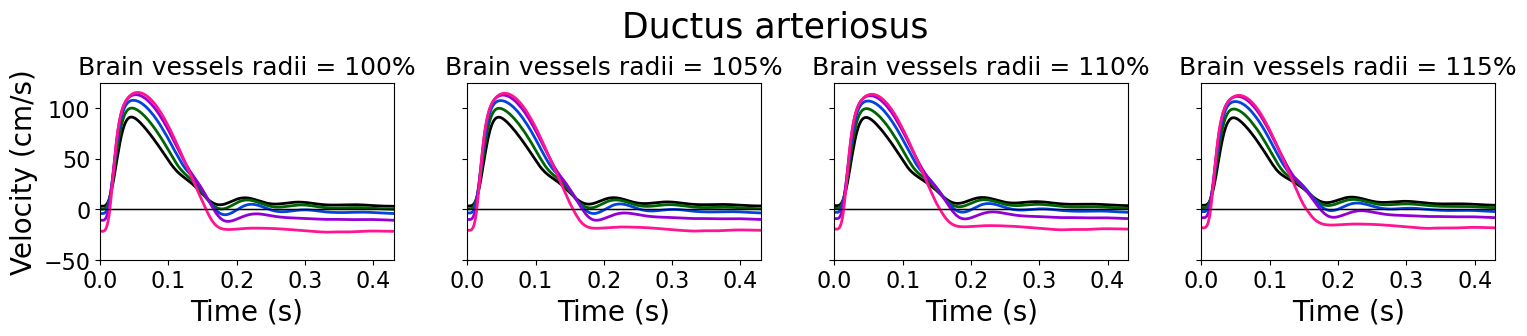

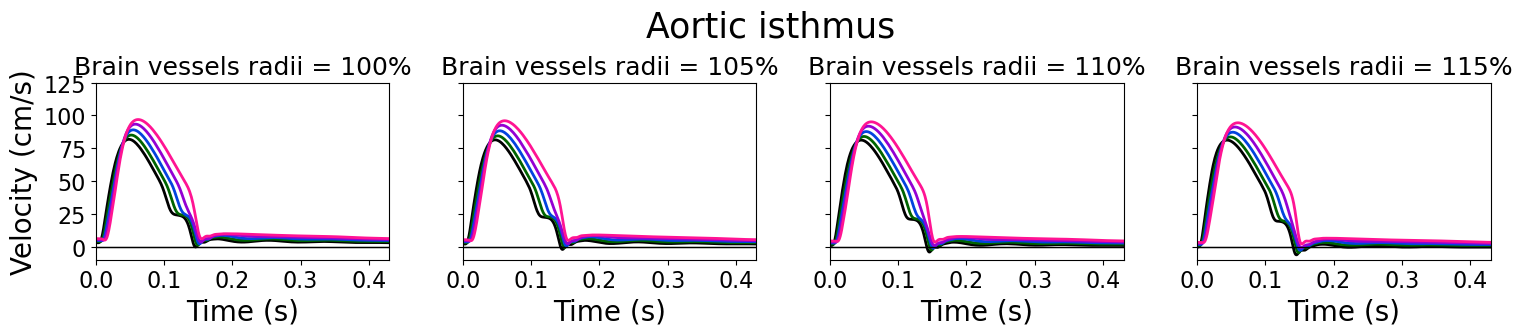

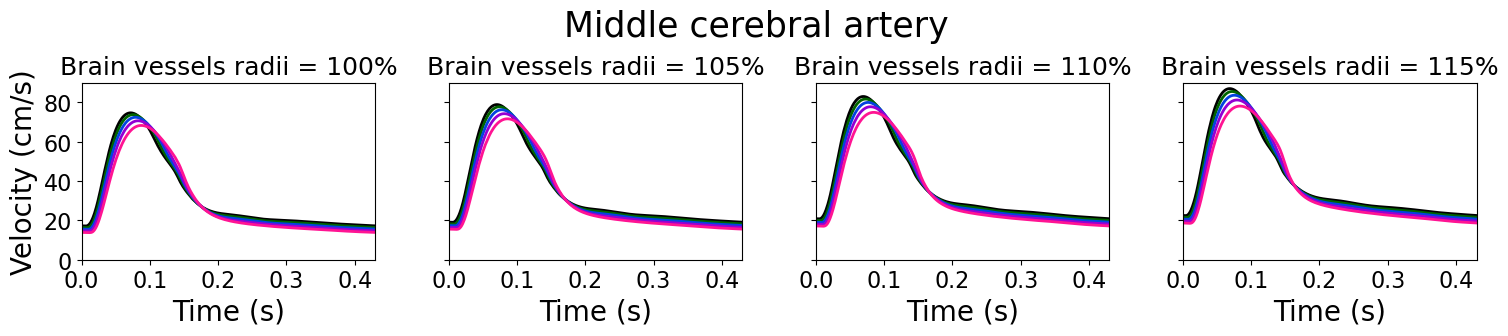

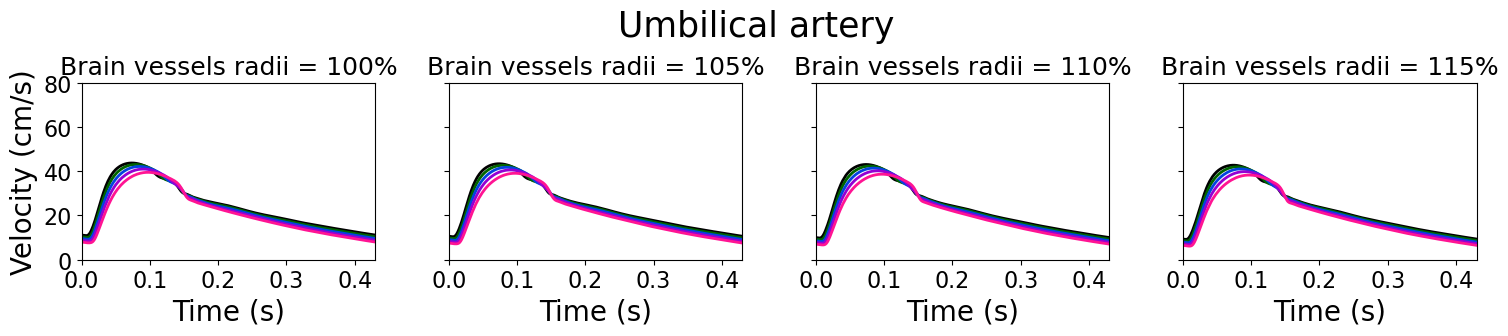

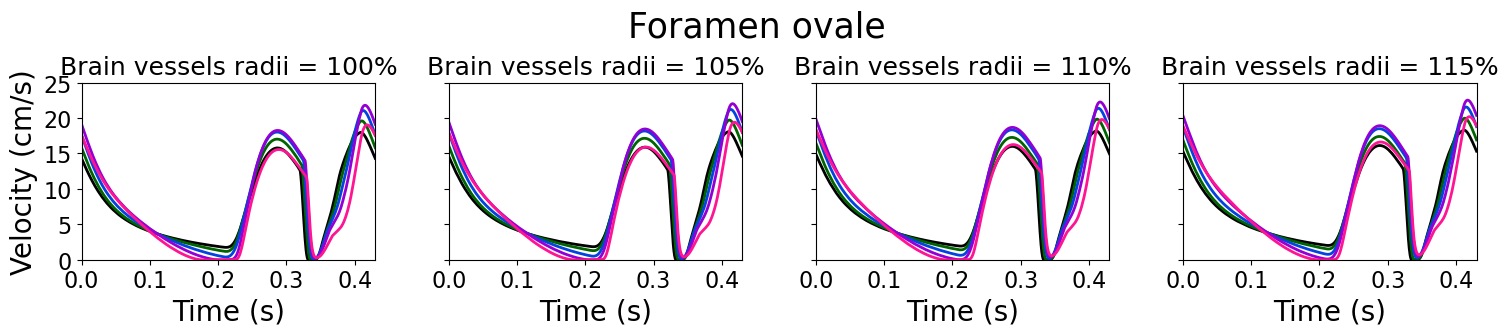

In [24]:
fo_curve = [1,0.8,0.6,0.4,0.2] 
da_curve = [1,0.9,0.8,0.7,0.6]
lung_curve = [1,0.8,0.65,0.55,0.47]
brain_curve = [1,1.35,1.98,3.39] 
brain_degree = [1,1.05,1.1,1.15]

v_colors = ['black','darkgreen','#0343DF','darkviolet','deeppink'] 

titles = ['Brain vessels radii = 100%', 'Brain vessels radii = 105%', 'Brain vessels radii = 110%', 'Brain vessels radii = 115%']  # ajusta
linewidth = 2
save_images = True

_, f = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f = f.flatten()
_, f1 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f1 = f1.flatten()
_, f2 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f2 = f2.flatten()
_, f3 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f3 = f3.flatten()
_, f4 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f4 = f4.flatten()
_, f5 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f5 = f5.flatten()
_, f6 = plt.subplots(ncols = 4, nrows = 1, figsize = (18, 2.3))
f6 = f6.flatten()

healthy_r_isthm = 0.2707 
healthy_r_da = 0.2328 
healthy_r_aa = 0.3129
healthy_r_mpa = 0.4146
healthy_r_mca = 0.185
r_ua = 0.2234

data = np.load("default_constants.npz", allow_pickle=True)   
default_constants = {key: data[key] for key in data}

for index_2 in range(len(brain_degree)):
    for index in range(len(fo_curve)):
        data = np.load(f"/Users/inmav/Downloads/Results_TGA_100/FO{int(round(fo_curve[index]*100))}_DA{int(round(da_curve[index]*100))}_LUNG{int(round(lung_curve[index]*100))}_DV100_BRAIN{int(round(brain_degree[index_2]*100))}.npz") 
        print(f"/Users/inmav/Downloads/Results_TGA_100/FO{int(round(fo_curve[index]*100))}_DA{int(round(da_curve[index]*100))}_LUNG{int(round(lung_curve[index]*100))}_DV100_BRAIN{int(round(brain_degree[index_2]*100))}.npz")
        t = data['voi'] - np.min(data['voi']) 
        results = data['data']  
        names = data['names'] 
        constants = data['constants']
        names_constants = data['names_constants']
        color = v_colors[index]

        Aao = constants[np.where(np.all(names_constants == ('Parameters','Apv'), axis=1))[0][0]] # TGA
        Ami = constants[np.where(np.all(names_constants == ('Parameters','Ami'), axis=1))[0][0]]
        Apv = constants[np.where(np.all(names_constants == ('Parameters','Aao'), axis=1))[0][0]]
        Atr = constants[np.where(np.all(names_constants == ('Parameters','Atr'), axis=1))[0][0]]
        Afo = constants[np.where(np.all(names_constants == ('Parameters','Afo'), axis=1))[0][0]]
        
        degree_isthm = (default_constants['Risthm']/constants[np.where(np.all(names_constants == ('Parameters','Risthm'), axis=1))[0][0]])**(1/4)
        r_isthm = healthy_r_isthm
        r_da = healthy_r_da*da_curve[index]

        degree_aa = (default_constants['Raa']/constants[np.where(np.all(names_constants == ('Parameters','Raa'), axis=1))[0][0]])**(1/4)
        r_aa = healthy_r_aa*degree_aa

        degree_mpa = (default_constants['Rpa']/constants[np.where(np.all(names_constants == ('Parameters','Rpa'), axis=1))[0][0]])**(1/4)
        r_mpa = healthy_r_mpa*degree_mpa

        degree_mca = (default_constants['Rsvc']/constants[np.where(np.all(names_constants == ('Parameters','Rsvc'), axis=1))[0][0]])**(1/4)
        r_mca = healthy_r_mca*degree_mca

        xi = results[:, np.where(np.all(names == ('LV', 'xi'), axis=1))[0][0]]
        Q_lv = results[:, np.where(np.all(names == ('LV', 'Qo'), axis=1))[0][0]]

        non_zero_indices = np.where(xi > 10**(-2))[0]
        first_non_zero_index = non_zero_indices[0]
        shifted_t = t[first_non_zero_index:] - t[first_non_zero_index]


        plt.sca(f[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('LV','Qo'), axis=1))[0][0]][first_non_zero_index:]/Aao,color=color,linestyle='-',label = 'Pv',linewidth=linewidth)
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('LA','Qo'), axis=1))[0][0]][first_non_zero_index:]/Ami,color=color,linestyle='--',label = 'Mv',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([0,125])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)
        if index == 0 and index_2 == 0:
            legend = f[index_2].legend(loc = 'upper right', fontsize=16)
            f[index_2].add_artist(legend)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Left heart', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_Left_heart_curves_v2.svg", format='svg', bbox_inches='tight')

        plt.sca(f1[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('RV','Qo'), axis=1))[0][0]][first_non_zero_index:]/Apv,color=color,linestyle='-',label = 'Av',linewidth=linewidth)
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('RA','Qo'), axis=1))[0][0]][first_non_zero_index:]/Atr,color=color,linestyle='--',label = 'Tv',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([0,125])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)
        if index == 0 and index_2 == 0:
            legend = f1[index_2].legend(loc = 'upper right', fontsize=16)
            f1[index_2].add_artist(legend)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Right heart', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_Right_heart_curves_v2.svg", format='svg', bbox_inches='tight')

        plt.sca(f2[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('Bif_PAin_LUNG1out_DA2out', 'Qo2'), axis=1))[0][0]][first_non_zero_index:]/(np.pi*r_da**2),color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([-50,125])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.axhline(y=0, color='k', linestyle='-', linewidth = 0.8)
        plt.title(titles[index_2], fontsize=18)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Ductus arteriosus', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_DA_curves_v2.svg", format='svg', bbox_inches='tight')        

        plt.sca(f3[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('AI_RCL', 'Qo'), axis=1))[0][0]][first_non_zero_index:]/(np.pi*r_isthm**2),color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([-10,125])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.axhline(y=0, color='k', linestyle='-', linewidth = 0.8)
        plt.title(titles[index_2], fontsize=18)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Aortic isthmus', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_AI_curves_v2.svg", format='svg', bbox_inches='tight') 

        GA = 36
        Tc = 0.43
        density = 1.05
        viscosity = (1.15+0.075*GA)/100
        Q_LICA = results[:,np.where(np.all(names == ('ICaroAL_RCL', 'Qo'), axis=1))[0][0]][first_non_zero_index:]
        Q_RICA = results[:,np.where(np.all(names == ('ICaroAR_RCL', 'Qo'), axis=1))[0][0]][first_non_zero_index:]
        Q_MCA = (Q_LICA + Q_RICA)*0.75*0.74312
        v_MCA = Q_MCA/(0.5*(np.pi*r_mca**2)) 
        
        print(f"MCA PI = {(np.max(v_MCA)-np.min(v_MCA))/np.mean(v_MCA)}")

        plt.sca(f4[index_2])
        plt.plot(shifted_t,v_MCA,color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([0,90])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Middle cerebral artery', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_MCA_curves_v2.svg", format='svg', bbox_inches='tight')            

        plt.sca(f5[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('Bif_AOin_LEG1out_UA2out', 'Qo2'), axis=1))[0][0]][first_non_zero_index:]/(np.pi*r_ua**2),color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([0,80])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Umbilical artery', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_UA_curves_v2.svg", format='svg', bbox_inches='tight') 

        
        plt.sca(f6[index_2])
        plt.plot(shifted_t,results[:,np.where(np.all(names == ('Bif_DV1in_IVC2in_FOout', 'Qo'), axis=1))[0][0]][first_non_zero_index:]/Afo,color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)',fontsize=20)
        plt.xlim([t[0],0.43])
        plt.ylim([0,25])
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)
        if index == 4 and index_2 == 0:
            plt.ylabel('Velocity (cm/s)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if fo_curve[index] == fo_curve[-1]:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Foramen ovale', fontsize=25, y=1.2)
        if save_images:
            plt.savefig(f"./Plots/100_FO_curves_v2.svg", format='svg', bbox_inches='tight') 


/Users/inmav/Downloads/Results_TGA_100/FO100_DA100_LUNG100_DV100_BRAIN100.npz
/Users/inmav/Downloads/Results_TGA_100/FO80_DA90_LUNG80_DV100_BRAIN100.npz
/Users/inmav/Downloads/Results_TGA_100/FO60_DA80_LUNG65_DV100_BRAIN100.npz
/Users/inmav/Downloads/Results_TGA_100/FO40_DA70_LUNG55_DV100_BRAIN100.npz
/Users/inmav/Downloads/Results_TGA_100/FO20_DA60_LUNG47_DV100_BRAIN100.npz
/Users/inmav/Downloads/Results_TGA_100/FO100_DA100_LUNG100_DV100_BRAIN105.npz
/Users/inmav/Downloads/Results_TGA_100/FO80_DA90_LUNG80_DV100_BRAIN105.npz
/Users/inmav/Downloads/Results_TGA_100/FO60_DA80_LUNG65_DV100_BRAIN105.npz
/Users/inmav/Downloads/Results_TGA_100/FO40_DA70_LUNG55_DV100_BRAIN105.npz
/Users/inmav/Downloads/Results_TGA_100/FO20_DA60_LUNG47_DV100_BRAIN105.npz
/Users/inmav/Downloads/Results_TGA_100/FO100_DA100_LUNG100_DV100_BRAIN110.npz
/Users/inmav/Downloads/Results_TGA_100/FO80_DA90_LUNG80_DV100_BRAIN110.npz
/Users/inmav/Downloads/Results_TGA_100/FO60_DA80_LUNG65_DV100_BRAIN110.npz
/Users/inmav/Dow

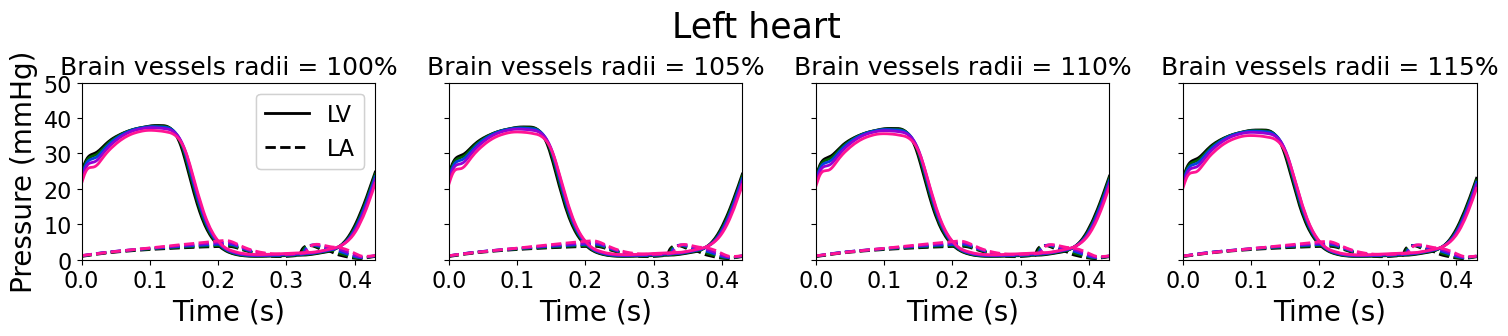

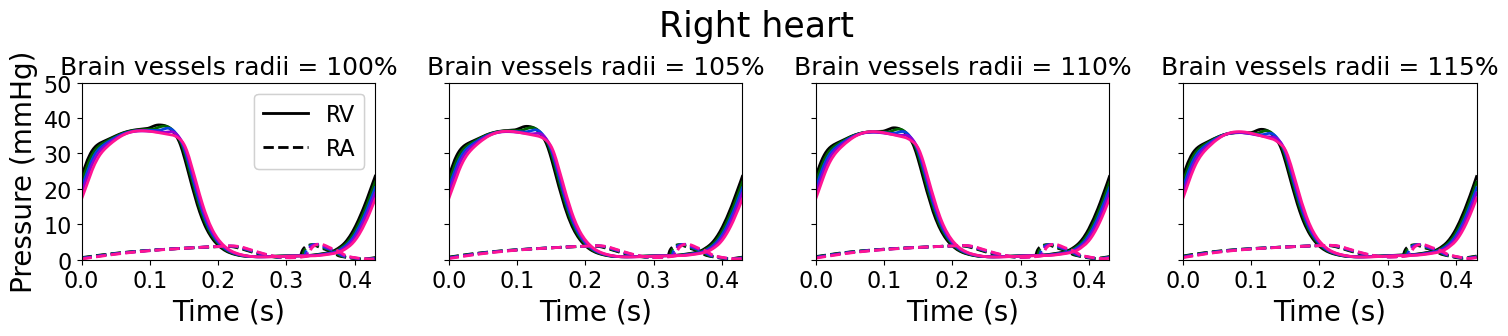

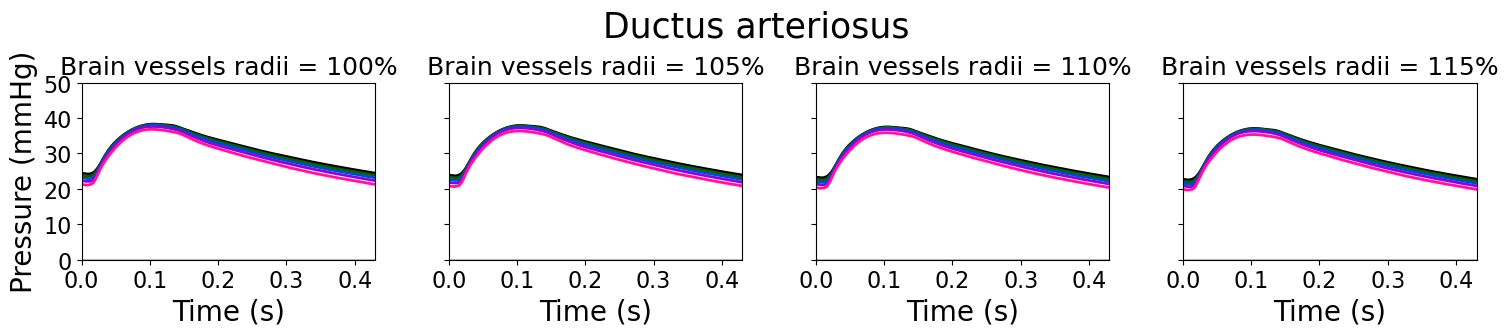

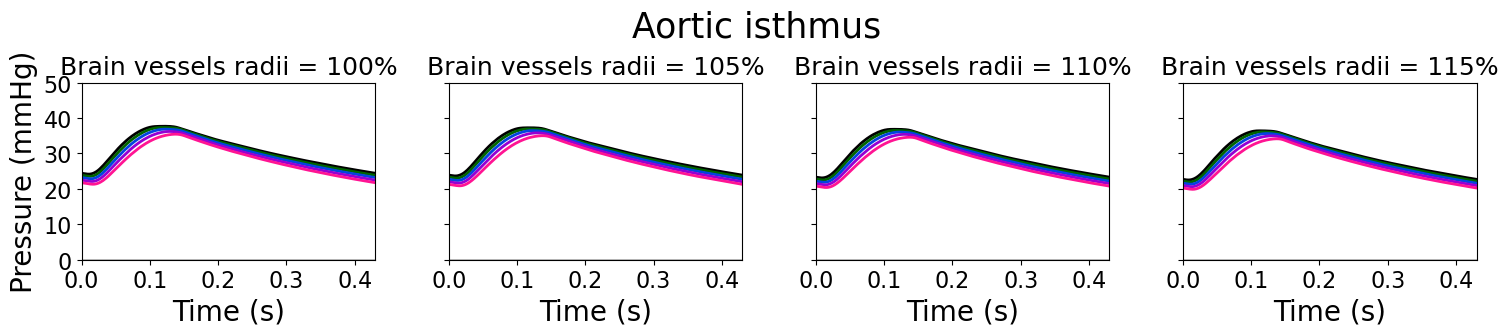

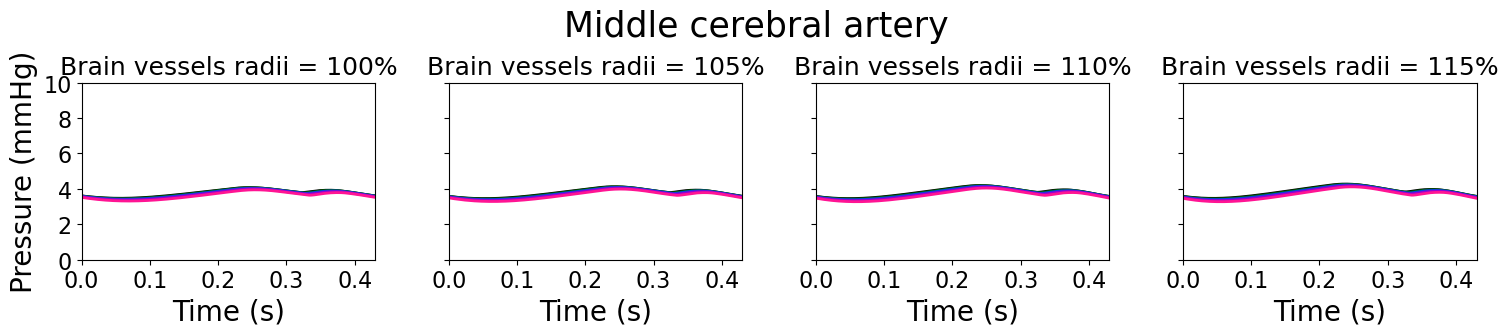

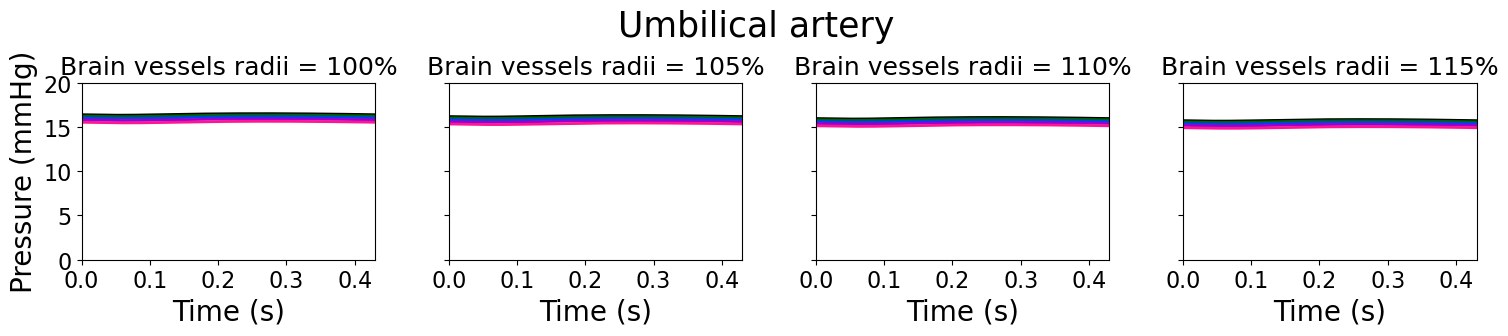

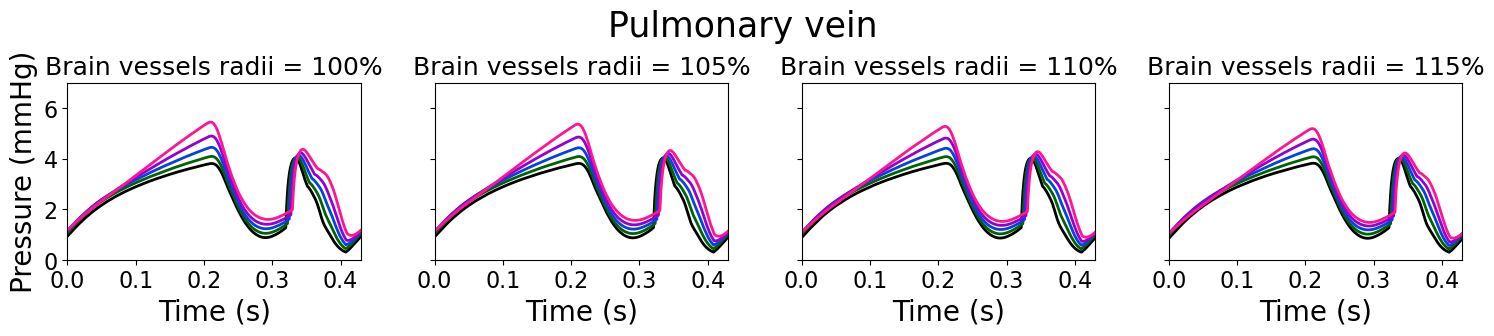

In [27]:
fo_curve = [1, 0.8, 0.6, 0.4, 0.2] 
da_curve = [1, 0.9, 0.8, 0.7, 0.6]
lung_curve = [1, 0.8, 0.65, 0.55, 0.47]

brain_curve = [1, 1.35, 1.98, 3.39]      
brain_degree = [1, 1.05, 1.1, 1.15]    

v_colors = ['black', 'darkgreen', '#0343DF', 'darkviolet', 'deeppink']

titles = ['Brain vessels radii = 100%','Brain vessels radii = 105%','Brain vessels radii = 110%','Brain vessels radii = 115%']

linewidth = 2
save_images = True

_, f = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f = f.flatten()
_, f1 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f1 = f1.flatten()
_, f2 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f2 = f2.flatten()
_, f3 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f3 = f3.flatten()
_, f4 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f4 = f4.flatten()
_, f5 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f5 = f5.flatten()
_, f6 = plt.subplots(ncols=4, nrows=1, figsize=(18, 2.3))
f6 = f6.flatten()


healthy_r_isthm = 0.2707 
healthy_r_da = 0.2328 
healthy_r_aa = 0.3129
healthy_r_mpa = 0.4146
healthy_r_mca = 0.185
r_ua = 0.2234

data = np.load("default_constants.npz", allow_pickle=True)   
default_constants = {key: data[key] for key in data}


for index_2 in range(len(brain_degree)):      
    for index in range(len(fo_curve)):       

        filename = (f"/Users/inmav/Downloads/Results_TGA_100/FO{int(round(fo_curve[index] * 100))}_DA{int(round(da_curve[index] * 100))}_LUNG{int(round(lung_curve[index] * 100))}_DV100_BRAIN{int(round(brain_degree[index_2] * 100))}.npz")
        print(filename)

        data = np.load(filename)

        t = data['voi'] - np.min(data['voi']) 
        results = data['data']  
        names = data['names'] 
        constants = data['constants']
        names_constants = data['names_constants']

        color = v_colors[index]

        xi = results[:, np.where(np.all(names == ('LV', 'xi'), axis=1))[0][0]]

        non_zero_indices = np.where(xi > 10**(-2))[0]
        first_non_zero_index = non_zero_indices[0]
        shifted_t = t[first_non_zero_index:] - t[first_non_zero_index]


        plt.sca(f[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('LV', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',label='LV',linewidth=linewidth)
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('LA', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='--',label='LA',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 50])
        plt.xticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)

        if index == 0 and index_2 == 0:
            legend = f[index_2].legend(loc='upper right', fontsize=16)
            f[index_2].add_artist(legend)
        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Left heart', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_Left_heart_curves_p2.svg", format='svg', bbox_inches='tight')


        plt.sca(f1[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('RV', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',label='RV',linewidth=linewidth)
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('RA', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='--',label='RA',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 50])
        plt.xticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)

        if index == 0 and index_2 == 0:
            legend = f1[index_2].legend(loc='upper right', fontsize=16)
            f1[index_2].add_artist(legend)
        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Right heart', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_Right_heart_curves_p2.svg", format='svg', bbox_inches='tight')


        plt.sca(f2[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('Bif_PAin_LUNG1out_DA2out', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 50])
        plt.xticks(fontsize=16)
        plt.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
        plt.title(titles[index_2], fontsize=18)

        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Ductus arteriosus', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_DA_curves_p2.svg", format='svg', bbox_inches='tight')


        plt.sca(f3[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('AI_RCL', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 50])
        plt.xticks(fontsize=16)
        plt.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
        plt.title(titles[index_2], fontsize=18)

        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Aortic isthmus', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_AI_curves_p2.svg", format='svg', bbox_inches='tight')


        P_LICA = results[:, np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi2'), axis=1))[0][0]][first_non_zero_index:]
        P_RICA = results[:, np.where(np.all(names == ('Bif_BRR1in_BRL2in_BRout', 'Pi1'), axis=1))[0][0]][first_non_zero_index:]     

        
        plt.sca(f4[index_2])
        plt.plot(shifted_t,(P_LICA + P_RICA) / 2,color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 10])
        plt.xticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)

        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Middle cerebral artery', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_MCA_curves_p2.svg", format='svg', bbox_inches='tight')


        plt.sca(f5[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('PLAC_RC', 'Pi'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 20])
        plt.xticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)

        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Umbilical artery', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_UA_curves_p2.svg", format='svg', bbox_inches='tight')
            
            
        plt.sca(f6[index_2])
        plt.plot(shifted_t,results[:, np.where(np.all(names == ('Bif_LUNG1in_FO2in_LAout', 'Pi1'), axis=1))[0][0]][first_non_zero_index:],color=color,linestyle='-',linewidth=linewidth)
        plt.xlabel('Time (s)', fontsize=20)
        plt.xlim([t[0], 0.43])
        plt.ylim([0, 7])
        plt.xticks(fontsize=16)
        plt.title(titles[index_2], fontsize=18)

        if index == 4 and index_2 == 0:
            plt.ylabel('Pressure (mmHg)',fontsize=20)
            plt.gca().tick_params(labelleft=True)
            plt.yticks(fontsize=16)
        else:
            plt.gca().tick_params(labelleft=False) 
        if index == len(fo_curve) - 1:
            plt.subplots_adjust(wspace=0.25)
            fig = plt.gcf()
            fig.suptitle('Pulmonary vein', fontsize=25, y=1.2)
        if save_images:
            plt.savefig("./Plots/100_Lung_curves_p2.svg", format='svg', bbox_inches='tight')

1.41
1.44
1.47
1.51
1.56
1.62
1.69
1.79
1.92


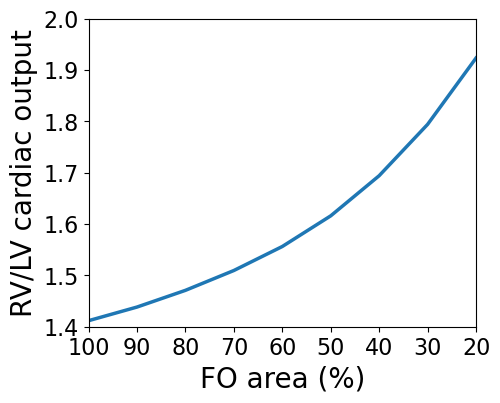

In [26]:
fo_curve = [1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2] 
fo_curve = [100,90,80,70,60,50,40,30,20] 
da_curve = [1,0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6]
lung_curve = [1,0.89,0.8,0.72,0.65,0.60,0.55,0.51,0.47]
brain_curve = [1] 
brain_degree = [1]
v_ratio = []

for index in range(len(fo_curve)):
    for index_2 in range(len(brain_curve)):
        data = np.load(f"/Users/inmav/Downloads/Results_TGA_100/FO{int(round(fo_curve[index]))}_DA{int(round(da_curve[index]*100))}_LUNG{int(round(lung_curve[index]*100))}_DV100_BRAIN{int(round(brain_curve[index_2]*100))}.npz") 
        t = data['voi'] - np.min(data['voi']) 
        results = data['data']  
        names = data['names'] 
        constants = data['constants']
        names_constants = data['names_constants']


        ratio = (np.trapz(results[:,np.where(np.all(names == ('RV','Qo'), axis=1))[0][0]],t)/2) / (np.trapz(results[:,np.where(np.all(names == ('LV','Qo'), axis=1))[0][0]],t)/2)
        print(np.round(ratio,2))
        v_ratio.append(ratio)

plt.figure(figsize=(5,4))
plt.plot(fo_curve,v_ratio,linewidth=2.5)
plt.xlabel('FO area (%)',fontsize=20)
plt.ylabel('RV/LV cardiac output',fontsize=20)
plt.xlim([100,20])
plt.ylim([1.4,2])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig(f"./Plots/100_RVLV_CO.svg", format='svg', bbox_inches='tight')
plt.show()
